# <span style="color:red; font-size:30px"> Lecture 25: Tips/Advice for Final Project </span>

<font size = "5">

**Presentation**


<font size = "4">

- When presenting results from a data analysis task, we want everything to be as professional looking as possible.

- We also want to make it as easy as possible for the reader follow along with what is happening in the code, and to easily interpret results.

- We also don't want to waste the reader's time by showing them extraneous output. (ALWAYS do "plt.show()")

<font size = "4">

To begin, it's a good idea to do all the module importing at the top, before all the other code.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

<font size = "4">

We saw how ugly warning messages looked after converting to HTML:

In [7]:
df_players = pd.read_csv("data/players_15.csv")

/var/folders/ms/gc0jjfl96jjfqsv8_dkxdr200000gn/T/ipykernel_4222/3857339696.py:1: DtypeWarning: Columns (104) have mixed types. Specify dtype option on import or set low_memory=False.
  df_players = pd.read_csv("data/players_15.csv")


<font size = "4">

- Since we are all high school graduates, we have the power of literacy at our disposal. I.e., we can **read** the warning message.

- At the end, it tells us how to eliminate the warning: "Specify dtype option on import or set low_memory=False."

- It gives us two options. The second sounds really easy; we just add an extra argument to `pd.read_csv` called "low_memory" and set it to False.

In [4]:
df_players = pd.read_csv("data/players_15.csv", low_memory = False)

<font size = "4">

- The warning is gone!

- It's a good habit to figure out how to resolve warnings individually. But, you can use the "warnings" module to suppress all warning messages in the notebook

- (You would want to include the next two lines of code in the same cell where you imported everything else)


In [5]:
import warnings
warnings.filterwarnings("ignore")

In [6]:
df_players = pd.read_csv("data/players_15.csv")

# No warning message is shown!

<font size = "4">

**Formatting output**

- Output should be shown for the reader's benefit. It should be informative and easy to digest.

- This is a **bad** example:

In [7]:
stats_15 = df_players.describe()

display(stats_15)

,sofifa_id,overall,potential,value_eur,wage_eur,age,height_cm,weight_kg,club_team_id,league_level,...,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,goalkeeping_speed
count,16155.000000,16155.000000,16155.000000,1.584400e+04,15916.000000,16155.000000,16155.000000,16155.000000,15916.000000,15916.000000,...,0.0,16155.000000,16155.000000,16155.000000,16155.000000,16155.000000,16155.000000,16155.000000,16155.000000,1775.000000
mean,189298.540699,63.830393,68.350108,1.081706e+06,13252.513194,24.776230,181.083627,75.474342,39905.174353,1.378424,...,NaN,45.009037,47.656639,45.885918,15.869514,15.511668,15.354875,15.504735,15.998514,43.865915
std,39762.547872,7.169896,6.580610,2.842704e+06,23608.922510,4.625321,6.618974,6.891796,52050.202038,0.736796,...,NaN,17.915206,18.743105,18.145497,17.576799,16.414173,16.010498,16.585081,17.983209,8.484421
min,2.000000,40.000000,40.000000,1.000000e+03,2000.000000,16.000000,155.000000,50.000000,1.000000,1.000000,...,NaN,20.000000,20.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,20.000000
25%,178042.500000,59.000000,64.000000,1.300000e+05,2000.000000,21.000000,176.000000,70.000000,379.000000,1.000000,...,NaN,25.000000,25.000000,25.000000,8.000000,8.000000,8.000000,8.000000,8.000000,39.000000
50%,200844.000000,64.000000,68.000000,3.500000e+05,5000.000000,24.000000,181.000000,75.000000,1843.000000,1.000000,...,NaN,46.000000,52.000000,49.000000,11.000000,11.000000,11.000000,10.000000,10.000000,44.000000
75%,214349.500000,68.000000,73.000000,8.250000e+05,10000.000000,28.000000,186.000000,80.000000,110398.000000,2.000000,...,NaN,61.000000,64.000000,62.000000,13.000000,14.000000,13.000000,13.000000,13.000000,49.000000
max,254664.000000,93.000000,95.000000,1.005000e+08,550000.000000,44.000000,204.000000,110.000000,113147.000000,4.000000,...,NaN,90.000000,91.000000,95.000000,88.000000,87.000000,92.000000,90.000000,90.000000,66.000000


<font size = "4">

- This is a table with SIXTY columns. That is completely absurd - no one wants to look at this.

- This table contains contains useless information. What does the mean value of "club_team_id" or "club_jersey_number" tell us?

- We want to restrict our attention to a smaller number of important variables

In [8]:
stats_15 = df_players[["overall", "potential", "shooting", "passing", "dribbling"]].describe()

display(stats_15)

,overall,potential,shooting,passing,dribbling
count,16155.000000,16155.000000,14380.000000,14380.000000,14380.000000
mean,63.830393,68.350108,51.582337,55.638665,60.525661
std,7.169896,6.580610,13.401158,10.725853,10.758680
min,40.000000,40.000000,22.000000,24.000000,25.000000
25%,59.000000,64.000000,41.000000,49.000000,54.000000
50%,64.000000,68.000000,53.000000,56.000000,62.000000
75%,68.000000,73.000000,62.000000,63.000000,68.000000
max,93.000000,95.000000,93.000000,91.000000,96.000000


<font size = "4">

- Only 5 columns, much easier to make sense of.

- But do we really need to know that the mean value of "overall" is 63.83039306716187? 

- Knowing the average is $\approx 63.83$ is probably all we need to communicate.

- So we can round to two digits before displaying:

In [9]:
stats_15 = df_players[["overall", "potential", "shooting", "passing", "dribbling"]].describe()

display(stats_15.round(2))

,overall,potential,shooting,passing,dribbling
count,16155.00,16155.00,14380.00,14380.00,14380.00
mean,63.83,68.35,51.58,55.64,60.53
std,7.17,6.58,13.40,10.73,10.76
min,40.00,40.00,22.00,24.00,25.00
25%,59.00,64.00,41.00,49.00,54.00
50%,64.00,68.00,53.00,56.00,62.00
75%,68.00,73.00,62.00,63.00,68.00
max,93.00,95.00,93.00,91.00,96.00


<font size = "4">

- Sometimes "count" is useful to know (the average of 10,000 values is more informative than the average of 2 values). But if you don't think it's important, you don't have to print out everything:



In [10]:
stats_15 = df_players[["overall", "potential", "shooting", "passing", "dribbling"]].describe()

display(stats_15.iloc[1:,:].round(2))

,overall,potential,shooting,passing,dribbling
mean,63.83,68.35,51.58,55.64,60.53
std,7.17,6.58,13.40,10.73,10.76
min,40.00,40.00,22.00,24.00,25.00
25%,59.00,64.00,41.00,49.00,54.00
50%,64.00,68.00,53.00,56.00,62.00
75%,68.00,73.00,62.00,63.00,68.00
max,93.00,95.00,93.00,91.00,96.00


<font size = "4">

- Or maybe you want to exclude the 25th and 75th percentiles

In [ ]:
stats_15 = df_players[["overall", "potential", "shooting", "passing", "dribbling"]].describe()

disp_rows = ["mean", "std", "min", "50%", "max"]

display(stats_15.loc[disp_rows,:].round(2))

<font size = "4">

**Other considerations**

- We'll end this example here, but it's worth thinking about *why* you are showing the data and how the reader should interpret it.

- Should the reader pay attention to the fact that specific skills like "shooting" and "passing" have a higher standard deviation than the general variables "overall" and "potential"?

- Or do you want to draw attention to the fact that "overall" and "potential" are very similar in terms of standard deviation, minimum, and maximum, but have different mean/median?

- Should you alter the dataset before generating these statistics? For example, maybe you should remove all the goalies and defenders before looking at the statistics for "shooting". Or maybe you should do that in a 2nd table and compare to the general statistics.

<font size = "5">

**Plots**

<font size = "4">

We'll talk more about how to make good plots in the last lecture (April 22nd). It's a good idea to polish your plots at the very end, as one of the last things you do. However, here are some quick points.

- The names you give Python variables do **not** belong in your plot. Here is Homework submission from last Fall:

In [ ]:
array = np.linspace(0, 2 * np.pi, num = 100)
vec_y1 = np.sin(array)
vec_y2 = np.cos(array)
labels = ['sin(x)', 'cos(x)']
list_vectors = [vec_y1, vec_y2]

for y, label in zip(list_vectors, labels):
    plt.plot(array, y, label = label)
    
plt.xlabel('x')
plt.legend()
plt.ylabel('vec_y1 and vec_y2')
plt.title("Plot of vec_y1 and vec_y2")
plt.show()

<font size = "4">

- Does "vec_y1" and "vec_y2" mean anything to anybody besides the person who used those as variable names in Python? If someone skims through the report and sees this title will they have any idea what it means?

- Even if these variable names were meaningful, the y-axis label is still poor. The 0.25 tick mark on the vertical axis does not corresponds to "vec_y1 and vec_y2" = 0.25. It corresponds to $y = 0.25$.

- The following is a much better plot:

In [ ]:
array = np.linspace(0, 2 * np.pi, num = 100)
vec_y1 = np.sin(array)
vec_y2 = np.cos(array)
labels = ['y = sin(x)', 'y = cos(x)']
list_vectors = [vec_y1, vec_y2]

for y, label in zip(list_vectors, labels):
    plt.plot(array, y, label = label)
    
plt.xlabel('x')
plt.legend()
plt.ylabel('y')
plt.title("Fundamental Trigonometric Functions")
plt.show()

<font size = "4">

- This one is even better:

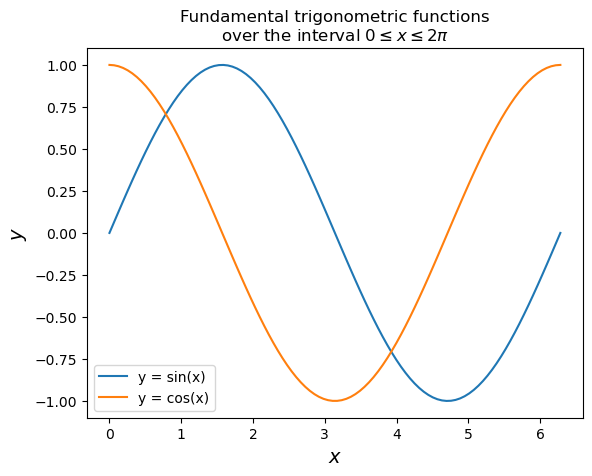

In [3]:
array = np.linspace(0, 2 * np.pi, num = 100)
vec_y1 = np.sin(array)
vec_y2 = np.cos(array)
labels = ['y = sin(x)', 'y = cos(x)']
list_vectors = [vec_y1, vec_y2]

for y, label in zip(list_vectors, labels):
    plt.plot(array, y, label = label)
    
plt.xlabel('$x$', fontsize = 14)
plt.legend()
plt.ylabel('$y$', fontsize = 14)
plt.title("Fundamental trigonometric functions\nover the interval $0\leq x \leq 2\pi$")
plt.show()

<font size = "4">

**Line plots**

- We haven't covered line plots in detail. But if data is properly sorted, its pretty straightforward to move from `plt.scatter` to `plt.plot`.

- Here, we plot the curve $y = x^2$ using both approaches. We'll enter the lists we're plotting manually

In [ ]:
x_vals = np.array([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])
x_sqrd = x_vals ** 2

plt.plot(x_vals, x_sqrd, 'r') # red line plot
plt.scatter(x_vals, x_sqrd, c = 'k') # blacK scatter plot
plt.show()

<font size = "4">

- We'll plot the same curve, but we will shuffle the values in `x_vals` before squaring them

In [ ]:
x_vals = np.array([1, 0.5, 0.8, 0.1, 0.9, 0, 0.3, 0.2, 0.7, 0.4, 0.6])
x_sqrd = x_vals ** 2

plt.plot(x_vals, x_sqrd, 'r') # red line plot
plt.scatter(x_vals, x_sqrd, c = 'k') # blacK scatter plot
plt.show()

<font size = "4">

- The scatter plot is fine, but the line plot doesn't look anything like $y = x^2$!

- `plt.plot` draws a sequence of straight lines, from point to point, based on how the values are ordered in the x-axis array.

- It draws a straight line from $(1, 1^2)$ to $(0.5, 0.5^2)$. Then a line from $(0.5, 0.5^2)$ to $(0.8, 0.8^2)$. Then a line from $(0.8, 0.8^2)$ to $(0.1, 0.1^2)$, and so on.

- If you use a line plot, make sure the values on the x-axis are sorted first!

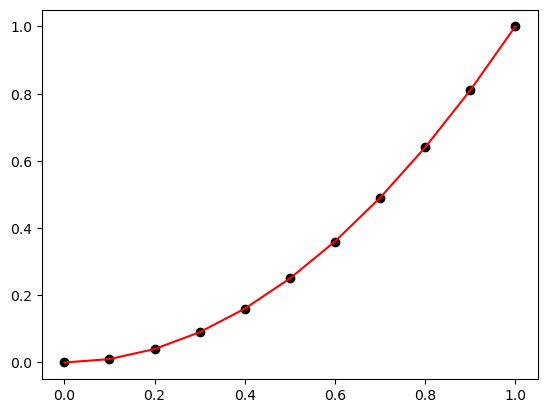

In [4]:
x_vals = np.array([1, 0.5, 0.8, 0.1, 0.9, 0, 0.3, 0.2, 0.7, 0.4, 0.6])
x_sqrd = x_vals ** 2

sort_ind = np.argsort(x_vals)

x_vals = x_vals[sort_ind]
x_sqrd = x_sqrd[sort_ind]

plt.plot(x_vals, x_sqrd, 'r') # red line plot
plt.scatter(x_vals, x_sqrd, c = 'k') # blacK scatter plot
plt.show()

<font size = "5">

**Using outside data sources**

<font size = "4">

- You should feel free to use information from outside the existing datasets to help come up with ideas.

- For example, if you are analyzing the 2020 U.S. election, you could ask a question like "How well does voter turnout rate correlate with a victory for Republican and Democratic Party candidates?" You would need to add population information from [census.gov](https://www.census.gov/)

- In practice quiz #4, I asked you to merge in "region" information to the 2020 presidential candidate data set. Once you investigate some relationship betweens variables in the dataset, you could see if this holds uniformly across all regions of the U.S. or if there are any regions where the relationship goes against the overarching trend.

- I created the following DataFrame by grabbing info about the four statistical regions defined by the U.S. Census Bureau from [Wikipedia](https://en.wikipedia.org/wiki/List_of_regions_of_the_United_States)



In [ ]:
state_lst = [
    "Alabama", "Alaska", "Arizona", "Arkansas", "California",
    "Colorado", "Connecticut", "Delaware", "District of Columbia", "Florida",
    "Georgia", "Hawaii", "Idaho", "Illinois", "Indiana", "Iowa",
    "Kansas", "Kentucky", "Louisiana", "Maine", "Maryland",
    "Massachusetts", "Michigan", "Minnesota", "Mississippi", "Missouri",
    "Montana", "Nebraska", "Nevada", "New Hampshire", "New Jersey",
    "New Mexico", "New York", "North Carolina", "North Dakota", "Ohio",
    "Oklahoma", "Oregon", "Pennsylvania", "Rhode Island", "South Carolina",
    "South Dakota", "Tennessee", "Texas", "Utah", "Vermont",
    "Virginia", "Washington", "West Virginia", "Wisconsin", "Wyoming"
]

region_lst = [
    "South", "West", "West", "South", "West",
    "West", "Northeast", "South", "South", "South",
    "South", "West", "West", "Midwest", "Midwest", "Midwest",
    "Midwest", "South", "South", "Northeast", "South",
    "Northeast", "Midwest", "Midwest", "South", "Midwest",
    "West", "Midwest", "West", "Northeast", "Northeast",
    "West", "Northeast", "South", "Midwest", "Midwest",
    "South", "West", "Northeast", "Northeast", "South",
    "Midwest", "South", "South", "West", "Northeast",
    "South", "West", "South", "Midwest", "West"
]

df_region = pd.DataFrame({"state": state_lst, "region":region_lst})

df_region.head()

In [ ]:
df_pres_county = pd.read_csv("data/president_county_candidate.csv")


df_merged = pd.merge(left = df_region[["region", "state"]],
            right = df_pres_county[["state", "county", "candidate", "total_votes"]],
            how = "right", 
            on = "state")

df_merged.head()

<font size = "4">

- Now I can calculate the vote totals across each region for each candidate. Let's do it for Gloria La Riva

In [ ]:
df_gloria = df_merged.query("candidate == 'Gloria La Riva'")

gloria_votes = df_gloria.groupby(by = "region").agg(votes=("total_votes", "sum"))

display(gloria_votes)

<font size = "4">

- **You can't always draw conclusions from raw counts.** 

- Gloria got 59,690 votes in Western states, way more than other regions. But does that tell us anything meaningful?

- California is a Western state and is the most highly populated state in the country. Is this just a consequence of that?

- Proportions/percentages can be more useful. We look at her total votes as a percentage of total votes cast.

In [ ]:
total_votes = df_merged.groupby(by="region").agg(votes=('total_votes','sum'))

display(100 * gloria_votes / total_votes) # multiply by 100 to make it a percent

<font size = "4">

- Yes, she did do better in the West. But we also found out that she had a proportionally stronger showing in the Midwest than the South, despite getting fewer votes.

- Something very similar to this was done by one group for the F1 dataset last semester. The group used the "nationality" column and divided that up into world region categories.

- They found that European drivers won the most races, then left it at that. But the large majority of F1 drivers are European to begin with, so this statistic really tells us **nothing**.

<font size = "4">

**Subsetting, Recoding, and Data Cleaning**

Data cleaning does not solely consist of removing or changing missing/incomplete values (but that is important too).

- Sometimes data is irrelevant for a given task. This doesn't mean it should be overwritten or discarded for the entire data analysis process, but maybe it should be ignored for certain questions.

- For example, Gloria La Riva was only on the ballot in 15 states:

In [ ]:
df_gloria["state"].nunique()

<font size = "4">

- So it might be a good idea to re-do our proportion/percentage calculation above, but only sum up the total votes for which she was on the ballot.

**Exercise:** Re-do the calculation of Gloria La Riva's proportionate vote total over regions, only using the states for which she appeared on the ballot. Try to perform this without hard-coding (i.e. don't *look* at what the 15 unique states are.)

In [ ]:
# your code here


<font size = "4">

- Sometimes we want to remove *outliers*. 

- These could be very large/small values of a given attribute, but it can crop up in more subtle ways.

- For example, in U.S. elections, candidates who are not Democrats or Republicans usually have very low vote totals. Individually, their votes totals might not be very meaningful. Very often they are all lumped together as "third party candidates".

- As another example, many drivers in the F1 dataset only appear for a single race. We might want to remove those before calculating statistics. 

In [5]:
df_results = pd.read_csv("data/results.csv")

driver_appearances = (df_results.groupby(by = "driverId").
                    agg(appearances = ('points', len)).
                    sort_values(by="appearances"))

print("Total drivers in dataset:", len(driver_appearances))             
print("# of drivers with only 1 appearance:",len(driver_appearances.query("appearances == 1")))

Total drivers in dataset: 854
# of drivers with only 1 appearance: 173


<font size = "4">

**Relationships between variables**

- We've mainly looked at the relationship between variables visually, using scatterplots, histograms, or barplots.

- We've also used linear regression in the homework assignments.

- We can also look form a *correlation* matrix using Pandas


In [8]:
df_reduced = df_players[[ "age", "height_cm", "shooting", "passing", "dribbling"]]
df_reduced.corr()

,age,height_cm,shooting,passing,dribbling
age,1.000000,0.085429,0.205109,0.306658,0.123303
height_cm,0.085429,1.000000,-0.170879,-0.256405,-0.401390
shooting,0.205109,-0.170879,1.000000,0.611521,0.755223
passing,0.306658,-0.256405,0.611521,1.000000,0.795019
dribbling,0.123303,-0.401390,0.755223,0.795019,1.000000


<font size = "4">

- Above, we see that shooting, passing, and dribbling are positively correlated - being better at passing correlates with being better at dribbling.

- Height seems to be negatively correlated with these variables - being taller correlates with weaker shooting, passing, and dribbling skills

<font size = "4">

**Plot examples**

- The best way to get ideas for plots and other visualization is by looking at what other people have done.

- See the [Matplotlib Example Gallery](https://matplotlib.org/stable/gallery/index.html) for a very wide variety of plots you can adapt for your own purposes.

- You can also check out the `seaborn` module for creating nice plots. Here is the [seaborn example gallery](https://seaborn.pydata.org/examples/index.html)

- For example, we can make a "heatmap" of the correlation matrix above using seaborn

In [ ]:
import seaborn

seaborn.heatmap(df_reduced.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("FIFA Correlation Matrix", fontsize=14)
plt.show()

<font size = "4">

**Interpreting your results**

- It's ok to have results that are ultimately inconclusive. What you **don't** want to do is make claims that are not supported by any evidence.

- Here is an excerpt from a project from last semester:

    - "In this project we seek to identify trends in the region winners are from, where success is measured by how often drivers finish on the podium (top 3 in each race). Using historical race results linked to driver nationalities, we group drivers into geographic regions and count how many podium finishes come from each region. **Results would indicate whether different societal and cultural expectations dictate race outcomes**." (Bold added by me)

- There is no way we can draw any conclusions about "societal and cultural expectations" from the F1 data set. Don't try and give your results more importance than they actually deserve.